# Dataset Cybersecurity Intrusion

Comment identifier une attaque en fonction de leur caractéristique reseau ?

## 1 - Setup

In [22]:
import os
import glob

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## 2 - Chargement du dataset

In [23]:
df = pd.read_csv("cybersecurity_intrusion_data.csv")

## 3 - Exploration des données

In [24]:
df

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,NaN,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


## 4 - Data Cleaning

In [25]:
def df_clean():
    df_c = df.copy()

    df_c.drop(columns=['session_id'], inplace=True)
    df_c = pd.get_dummies(df_c, columns=['encryption_used'], prefix='is')
    df_c = pd.get_dummies(df_c, columns=['browser_type'], prefix='used')
    df_c = pd.get_dummies(df_c, columns=['protocol_type'], prefix='used')

    return df_c

df_cleaned = pd.DataFrame()
df_cleaned = df_clean()
df_cleaned

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,is_AES,is_DES,used_Chrome,used_Edge,used_Firefox,used_Safari,used_Unknown,used_ICMP,used_TCP,used_UDP
0,599,4,492.983263,0.606818,1,0,1,False,True,False,True,False,False,False,False,True,False
1,472,3,1557.996461,0.301569,0,0,0,False,True,False,False,True,False,False,False,True,False
2,629,3,75.044262,0.739164,2,0,1,False,True,True,False,False,False,False,False,True,False
3,804,4,601.248835,0.123267,0,0,1,False,True,False,False,False,False,True,False,False,True
4,453,5,532.540888,0.054874,1,0,0,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9532,194,3,226.049889,0.517737,3,0,1,True,False,True,False,False,False,False,True,False,False
9533,380,3,182.848475,0.408485,0,0,0,False,False,True,False,False,False,False,False,True,False
9534,664,5,35.170248,0.359200,1,0,0,True,False,False,False,True,False,False,False,True,False
9535,406,4,86.664703,0.537417,1,1,0,True,False,True,False,False,False,False,False,True,False


In [26]:
df_cleaned_packet = df_cleaned[df_cleaned["network_packet_size"] <= 1500].copy() #Permet de retirer les lignes ou "network_packet_size" et superieur à 1500

print("Taille avant filtrage :", df_cleaned.shape)
print("Taille après filtrage :", df_cleaned_packet.shape)

df_cleaned_packet.head()

Taille avant filtrage : (9537, 17)
Taille après filtrage : (9537, 17)


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,is_AES,is_DES,used_Chrome,used_Edge,used_Firefox,used_Safari,used_Unknown,used_ICMP,used_TCP,used_UDP
0,599,4,492.983263,0.606818,1,0,1,False,True,False,True,False,False,False,False,True,False
1,472,3,1557.996461,0.301569,0,0,0,False,True,False,False,True,False,False,False,True,False
2,629,3,75.044262,0.739164,2,0,1,False,True,True,False,False,False,False,False,True,False
3,804,4,601.248835,0.123267,0,0,1,False,True,False,False,False,False,True,False,False,True
4,453,5,532.540888,0.054874,1,0,0,True,False,False,False,True,False,False,False,True,False


In [27]:
df_cleaned_no_outliers = df_cleaned.copy()

columns_to_filter = ['session_duration', 'login_attempts', 'failed_logins', 'ip_reputation_score']

for col in columns_to_filter:
    Q1 = df_cleaned_no_outliers[col].quantile(0.25)
    Q3 = df_cleaned_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_cleaned_no_outliers = df_cleaned_no_outliers[
        (df_cleaned_no_outliers[col] >= lower_bound) &
        (df_cleaned_no_outliers[col] <= upper_bound)
    ]



print("Taille avant outliers :", df_cleaned.shape)
print("Taille après outliers :", df_cleaned_no_outliers.shape)

df_cleaned_no_outliers

Taille avant outliers : (9537, 17)
Taille après outliers : (8608, 17)


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,is_AES,is_DES,used_Chrome,used_Edge,used_Firefox,used_Safari,used_Unknown,used_ICMP,used_TCP,used_UDP
0,599,4,492.983263,0.606818,1,0,1,False,True,False,True,False,False,False,False,True,False
1,472,3,1557.996461,0.301569,0,0,0,False,True,False,False,True,False,False,False,True,False
2,629,3,75.044262,0.739164,2,0,1,False,True,True,False,False,False,False,False,True,False
3,804,4,601.248835,0.123267,0,0,1,False,True,False,False,False,False,True,False,False,True
4,453,5,532.540888,0.054874,1,0,0,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9531,746,7,315.151758,0.190059,3,0,1,False,True,True,False,False,False,False,False,True,False
9532,194,3,226.049889,0.517737,3,0,1,True,False,True,False,False,False,False,True,False,False
9533,380,3,182.848475,0.408485,0,0,0,False,False,True,False,False,False,False,False,True,False
9534,664,5,35.170248,0.359200,1,0,0,True,False,False,False,True,False,False,False,True,False


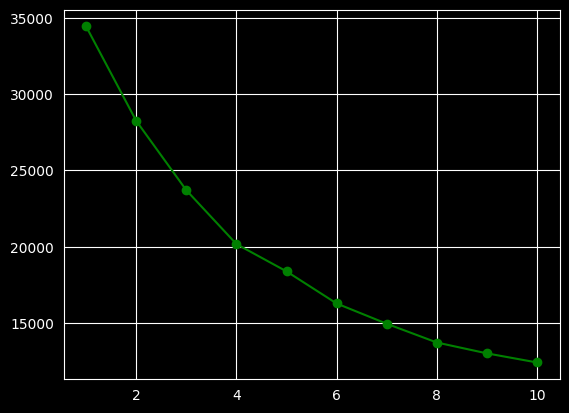

In [28]:
features = df_cleaned_no_outliers[['session_duration', 'login_attempts', 'failed_logins', 'ip_reputation_score']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

inertias = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, marker='o', color='green')

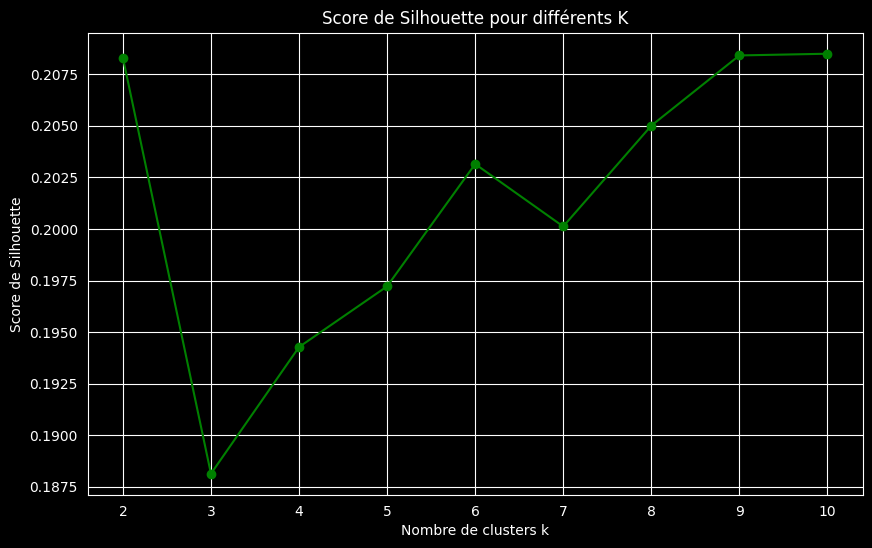

In [29]:
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

# Trace la courbe du score de silhouette
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title("Score de Silhouette pour différents K")
plt.xlabel("Nombre de clusters k")
plt.ylabel("Score de Silhouette")
plt.grid(True)
plt.show()

In [30]:
# analyse de la  silouhette : le meilleur k est à 10, mais il reste bas, donc les cluster ne sont pas très bien séparé

In [31]:
features = df_cleaned_no_outliers[
    ['session_duration', 'login_attempts', 'failed_logins', 'ip_reputation_score']
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [32]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_cleaned_no_outliers['cluster'] = kmeans.fit_predict(scaled_features)

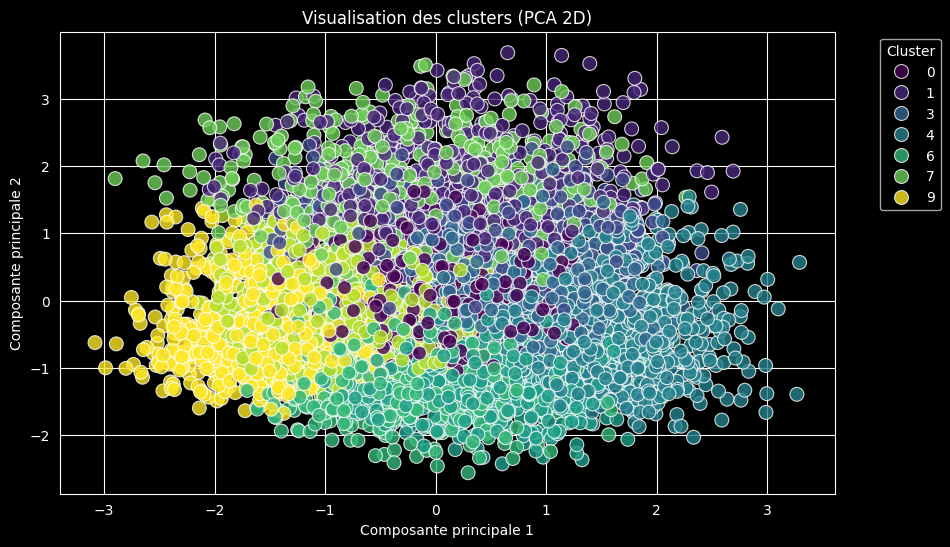

In [33]:
pca = PCA(n_components=2)
features_pca = pca.fit_transform(scaled_features)

# Ajout des composantes principales au DataFrame
df_cleaned_no_outliers['x'] = features_pca[:, 0]
df_cleaned_no_outliers['y'] = features_pca[:, 1]

# Tracé avec Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cleaned_no_outliers,
    x='x',
    y='y',
    hue='cluster',
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Visualisation des clusters (PCA 2D)')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

## Supervisé

### 1 - Setup

In [34]:
df = pd.read_csv("cybersecurity_intrusion_data.csv")

### 2 - Data cleaning

In [35]:
def df_clean():
    df_c = df.copy()

    df_c.drop(columns=['session_id'], inplace=True)
    df_c = pd.get_dummies(df_c, columns=['encryption_used'], prefix='is', drop_first=True)
    df_c = pd.get_dummies(df_c, columns=['browser_type'], prefix='used', drop_first=True)
    df_c = pd.get_dummies(df_c, columns=['protocol_type'], prefix='used', drop_first=True)

    return df_c

df_cleaned = pd.DataFrame()
df_cleaned = df_clean()
df_cleaned.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [36]:
df_cleaned_no_outliers = df_cleaned.copy()

columns_to_filter = ['session_duration', 'login_attempts', 'failed_logins', 'ip_reputation_score']

for col in columns_to_filter:
    Q1 = df_cleaned_no_outliers[col].quantile(0.25)
    Q3 = df_cleaned_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_cleaned_no_outliers = df_cleaned_no_outliers[
        (df_cleaned_no_outliers[col] >= lower_bound) &
        (df_cleaned_no_outliers[col] <= upper_bound)
    ]

print("Taille avant outliers :", df_cleaned.shape)
print("Taille après outliers :", df_cleaned_no_outliers.shape)

df_cleaned_no_outliers

Taille avant outliers : (9537, 14)
Taille après outliers : (8608, 14)


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,is_DES,used_Edge,used_Firefox,used_Safari,used_Unknown,used_TCP,used_UDP
0,599,4,492.983263,0.606818,1,0,1,True,True,False,False,False,True,False
1,472,3,1557.996461,0.301569,0,0,0,True,False,True,False,False,True,False
2,629,3,75.044262,0.739164,2,0,1,True,False,False,False,False,True,False
3,804,4,601.248835,0.123267,0,0,1,True,False,False,False,True,False,True
4,453,5,532.540888,0.054874,1,0,0,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9531,746,7,315.151758,0.190059,3,0,1,True,False,False,False,False,True,False
9532,194,3,226.049889,0.517737,3,0,1,False,False,False,False,False,False,False
9533,380,3,182.848475,0.408485,0,0,0,False,False,False,False,False,True,False
9534,664,5,35.170248,0.359200,1,0,0,False,False,True,False,False,True,False


In [37]:
X = df_cleaned_no_outliers.drop(columns=['attack_detected'])
Y = df_cleaned_no_outliers['attack_detected']

print("X (features) :")
print(X.head())
print("\nY (target) :")
print(Y.head())

X (features) :
   network_packet_size  login_attempts  session_duration  ip_reputation_score  \
0                  599               4        492.983263             0.606818   
1                  472               3       1557.996461             0.301569   
2                  629               3         75.044262             0.739164   
3                  804               4        601.248835             0.123267   
4                  453               5        532.540888             0.054874   

   failed_logins  unusual_time_access  is_DES  used_Edge  used_Firefox  \
0              1                    0    True       True         False   
1              0                    0    True      False          True   
2              2                    0    True      False         False   
3              0                    0    True      False         False   
4              1                    0   False      False          True   

   used_Safari  used_Unknown  used_TCP  used_UDP  
0 

In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,  # 20% des données pour le test
    random_state=42,
    stratify=Y  # Conserve la même proportion de classes dans train et test
)

In [39]:
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

           0       0.86      1.00      0.92      1017
           1       0.99      0.76      0.86       705

    accuracy                           0.90      1722
   macro avg       0.92      0.88      0.89      1722
weighted avg       0.91      0.90      0.90      1722

AUC-ROC: 0.88


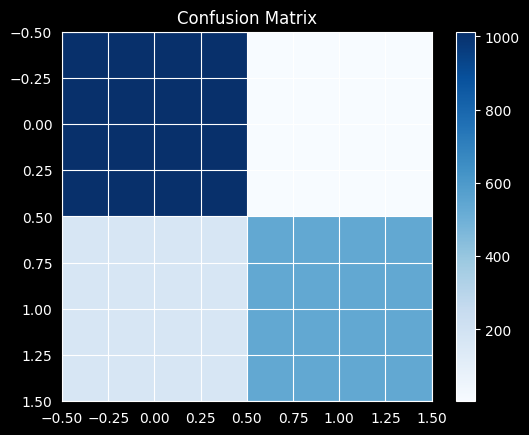

In [40]:
Y_pred = model.predict(X_test)
Y_proba = model.predict_proba(X_test)[:, 1]

# Rapport de classification
print(classification_report(Y_test, Y_pred))
print(f"AUC-ROC: {roc_auc_score(Y_test, Y_proba):.2f}")

cm = confusion_matrix(Y_test, Y_pred)

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [41]:
import joblib

joblib.dump(model, 'modele_detection_attaques.pkl')

['modele_detection_attaques.pkl']

In [43]:
df_cleaned_no_outliers.drop(columns=["attack_detected"]).to_csv("test_clean.csv", index=False)

In [46]:
df_cleaned_no_outliers[["attack_detected"]].to_csv("attack_detected.csv", index=False)